# 커머스 시계열 구성과 데이터 드리프트 탐색

**날짜:** 2026-08-13  
**목표:** 공개 커머스 데이터가 어떤 grain·엔티티·지표로 구성되는지 펼쳐 보고, 드리프트를 어떤 층에서 측정·시각화할 수 있는지 재현한다.

이번 노트북에서 실제로 읽는 데이터는 인증 없이 받을 수 있는 세 가지다.

| 데이터 | grain | 기간 | 라이선스 |
|---|---|---|---|
| UCI Online Retail II | invoice line | 2009-12 ~ 2011-12 | CC BY 4.0 |
| Olist Brazilian E-Commerce | order / item / product / payment | 2016-09 ~ 2018-10 | CC BY-NC-SA 4.0 |
| Tableau Sample Superstore | order line | 2014 ~ 2017 (샘플) | Tableau 교육 샘플 |

## 커머스 용어 정리

이 노트북에서 반복해서 나오는 용어다. 지표·엔티티·운영 축을 먼저 맞춰 두면 드리프트 해석이 쉬워진다.

### 엔티티 / 구조

| 용어 | 의미 |
|---|---|
| **SKU** (Stock Keeping Unit) | 재고·판매를 관리하는 최소 상품 단위. 같은 티셔츠라도 색/사이즈가 다르면 SKU가 다르다. |
| **Item / Product** | 상품. SKU보다 상위(또는 동일)로 쓰이기도 한다. M5의 `item_id`는 SKU에 가깝다. |
| **Category / Department / Family** | 상품 분류 계층. 예: Foods → FOODS_1 → FOODS_1_001. |
| **Store / Seller** | 판매 지점 또는 마켓플레이스 판매자. |
| **Customer / User** | 구매자. 익명화된 ID로 나타나는 경우가 많다. |
| **Order / Invoice** | 주문(또는 영수증). 여러 라인(상품 행)을 묶는 단위. |
| **Order line / Invoice line** | 주문 안의 한 상품 행. `qty × unit_price`가 보통 여기서 계산된다. |
| **Grain** | 데이터 한 행이 의미하는 해상도. 예: invoice line, store×SKU×day. |

### 매출·규모 KPI

| 용어 | 의미 | 대략적 정의 |
|---|---|---|
| **GMV** (Gross Merchandise Value) | 거래액/총상품가치. 플랫폼·리테일에서 “팔린 금액”의 기본 규모 지표. | `sum(qty × unit_price)` (취소 제외 여부는 정의에 따름) |
| **Revenue / Sales** | 매출. GMV와 같게 쓰이기도 하고, 할인·취소를 반영한 순매출을 뜻하기도 한다. | 데이터셋마다 정의 확인 필요 |
| **Units** | 판매 수량. | `sum(quantity)` |
| **Orders** | 주문 수. | `nunique(order_id)` |
| **AOV** (Average Order Value) | 객단가. 주문 1건당 평균 금액. | `GMV / Orders` |
| **ASP** (Average Selling Price) | 평균 판매 단가. | `GMV / Units` |
| **Cancel rate** | 취소(또는 반품) 비율. | 취소 라인(또는 주문) / 전체 |

### 구성·운영 지표

| 용어 | 의미 |
|---|---|
| **Mix (구성/믹스)** | 카테고리·국가·결제수단·점포 등이 전체에서 차지하는 **점유율**. 총량이 같아도 구성이 바뀌면 드리프트다. |
| **Share** | 특정 그룹의 비중. 예: `FOODS GMV / total GMV`. |
| **Churn (카탈로그)** | 비교 구간 사이 SKU/셀러 집합의 생성·소멸. 고객 이탈과 다른 “상품 카탈로그 churn”. |
| **SLA / Delivery days** | 배송 리드타임·약정 준수. Olist의 배송일수·지연일이 여기에 해당. |
| **Promo rate** | 프로모션이 걸린 관측 비율. Favorita의 `onpromotion` 비중. |
| **Reorder rate** | 재구매(이전에 산 상품을 다시 담는) 비율. Instacart의 `reordered`. |

### 드리프트 측정에서 자주 쓰는 말

| 용어 | 의미 |
|---|---|
| **Baseline / Current** | 비교의 기준 구간 vs 관심 구간. |
| **PSI** | Population Stability Index. 분포 변화의 대표 지표. 값이 클수록 분포가 더 달라진 것. |
| **TV / JS** | Total Variation / Jensen–Shannon. 카테고리 믹스(점유율) 차이에 자주 쓴다. |
| **Volume / Mix / Price 분해** | GMV 변화를 수량·구성·단가 기여로 나누는 해석. |

> 같은 이름이라도 데이터셋마다 정의가 조금 다르다. 각 섹션에서 “취소 포함 여부”, “gross vs net”를 함께 보면 된다.


## 0. 환경

가상환경은 `v3/.venv` 를 사용한다. 노트북 작업 디렉터리는 `notebooks/` 를 기준으로 한다.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", module="matplotlib")
sns.set_theme(style="whitegrid", context="notebook")

NB_ROOT = Path.cwd()
if not (NB_ROOT / "lib").exists():
    NB_ROOT = Path.cwd() / "notebooks"
sys.path.insert(0, str(NB_ROOT))

from lib.datasets import DATASET_CATALOG, download_all, load_olist, load_superstore, load_uci_online_retail_ii
from lib.drift import compare_windows, revenue_decomposition, rolling_drift, total_variation
from lib.metrics import commerce_daily_metrics, entity_churn, mix_shares
from lib.plotting import configure_matplotlib, finish_figure, format_date_axis, plot_metric_stack, style_area

font = configure_matplotlib()
print("NB_ROOT:", NB_ROOT)
print("pandas", pd.__version__, "| font:", font)


NB_ROOT: /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v3/notebooks
pandas 3.0.5 | font: AppleGothic


## 1. 오픈소스 커머스 데이터셋 지형

커머스 시계열은 한 줄짜리 "매출 시계열"이 아니다. 보통 아래 층이 겹쳐 있다.

- **이벤트 grain:** 클릭 / 장바구니 / 결제 / 취소 / 배송 / 리뷰
- **엔티티:** 고객, SKU, 카테고리, 셀러, 채널, 지역
- **파생 KPI:** GMV, 주문수, AOV, 취소비, 배송 SLA, 리뷰 점수
- **구성(mix):** 카테고리·국가·결제수단 점유율. 총량이 같아도 구성이 바뀌면 드리프트다.

Kaggle 인증이 필요한 M5, Favorita, Instacart는 카탈로그에만 남기고, 이번 실험에서는 직접 다운로드 가능한 셋을 연다.

In [2]:
catalog = pd.DataFrame(DATASET_CATALOG)
display(catalog[["id", "name", "grain", "period", "license", "access", "why"]])

,id,name,grain,period,license,access,why
0,uci_online_retail_ii,UCI Online Retail II,invoice line (주문 라인),2009-12 ~ 2011-12,CC BY 4.0,직접 다운로드,거래 원장 시계열. GMV/취소/국가 믹스/SKU 카탈로그 드리프트에 적합.
1,olist,Olist Brazilian E-Commerce,order + order_item + product + payment (관계형),2016-09 ~ 2018-10,CC BY-NC-SA 4.0,GitHub 미러 (원본은 Kaggle),주문 상태/배송 SLA/카테고리/결제수단 등 운영 시계열과 믹스 시프트.
2,superstore,Tableau Sample Superstore,order line,2014 ~ 2017 (샘플),Tableau 샘플 (교육용),공개 gist CSV,카테고리/세그먼트/지역 믹스가 깔끔해 구성 변화 시각화에 좋음.
3,uci_online_retail,UCI Online Retail (1년),invoice line,2010-12 ~ 2011-12,CC BY 4.0,참고용 (이번 실험에서는 II 사용),Online Retail II의 부분집합. II를 쓰면 별도 다운로드 불필요.
4,m5,M5 Walmart Forecasting,SKU x store x day,2011-01 ~ 2016-06,대회 데이터 (Academic / Non-Commercial),kagglehub.competition_download (Rules 수락 필요),계층 시계열(점포-카테고리-SKU) 수요·믹스 드리프트 벤치마크.
5,instacart,Instacart Market Basket 2017,order + order_product,"상대 시간(dow/hour, days_since_prior)",CC0-1.0 (Kaggle 미러),Kaggle API (access_token),재구매/장바구니 구성 드리프트. 절대 날짜 대신 order_number 축.
6,favorita,Corporación Favorita Store Sales,store x family x day,2013-01 ~ 2017-08,대회 데이터,Kaggle API (Rules 수락된 계정),프로모션/휴일/유가 공변량과 점포·카테고리 수요 시계열.


## 2. 데이터 다운로드

캐시는 `notebooks/data/` 에 둔다. 이미 있으면 다시 받지 않는다.

In [3]:
paths = download_all()
for key, path in paths.items():
    print(f"{key:24s} {path}  exists={Path(path).exists()}")

uci_online_retail_ii     /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v3/notebooks/data/uci_online_retail_ii/online_retail_II.xlsx  exists=True
olist                    /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v3/notebooks/data/olist  exists=True
superstore               /Users/bhc/dev/datadrift/v1/datadrift_app_engine/v3/notebooks/data/superstore/superstore.csv  exists=True


## 3. UCI Online Retail II — 거래 원장 스키마

한 행 = 인보이스 라인. 주문(Invoice), 상품(StockCode), 고객, 국가가 같은 테이블에 붙어 있다.
`InvoiceNo` 가 `C` 로 시작하면 취소다. 음수 수량도 취소/반품 신호다.

In [4]:
retail = load_uci_online_retail_ii()
print(retail.shape)
print(retail.dtypes)
display(retail.head(3))
print("기간:", retail["InvoiceDate"].min(), "~", retail["InvoiceDate"].max())
print("국가 수:", retail["Country"].nunique(), "/ SKU 수:", retail["StockCode"].nunique())
print("고객(결측 제외):", retail["CustomerID"].nunique(), "/ 라인 결측 고객 비율:", (~retail["HasCustomer"]).mean().round(4))
print("취소 라인 비율:", retail["IsCancel"].mean().round(4))
display(retail.isna().mean().rename("missing_ratio").to_frame().T)

(1067371, 15)
InvoiceNo                 str
StockCode                 str
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
Customer ID           float64
Country                   str
Revenue               float64
IsCancel                 bool
HasCustomer              bool
CustomerID            float64
Date           datetime64[us]
YearMonth                 str
Weekday                   str
dtype: object


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country,Revenue,IsCancel,HasCustomer,CustomerID,Date,YearMonth,Weekday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,False,True,13085.0,2009-12-01,2009-12,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,False,True,13085.0,2009-12-01,2009-12,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,False,True,13085.0,2009-12-01,2009-12,Tuesday


기간: 2009-12-01 07:45:00 ~ 2011-12-09 12:50:00
국가 수: 43 / SKU 수: 5305
고객(결측 제외): 5942 / 라인 결측 고객 비율: 0.2277
취소 라인 비율: 0.0215


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country,Revenue,IsCancel,HasCustomer,CustomerID,Date,YearMonth,Weekday
missing_ratio,0.0,0.0,0.004105,0.0,0.0,0.0,0.227669,0.0,0.0,0.0,0.0,0.227669,0.0,0.0,0.0


### 커머스 KPI 카탈로그

라인 원장에서 바로 만들 수 있는 시계열 슬롯.

| 층 | 지표 | 정의 | 드리프트에서 보는 것 |
|---|---|---|---|
| 규모 | GMV | `qty * unit_price` 합 | 수준 이동, 분산, 계절 |
| 규모 | orders / lines / units | 인보이스·라인·수량 | 볼륨 vs 객단가 분리 |
| 단가 | AOV, ASP | GMV/주문, GMV/수량 | 가격·할인 드리프트 |
| 품질 | cancel_rate | 취소 라인 비율 | 운영/정책 변화 |
| 인구 | unique_customers | 일별 활성 고객 | 유입 구성 변화 |
| 구성 | country / SKU share | 매출 점유율 | 믹스 시프트 |
| 카탈로그 | new/dropped SKU | 윈도우 간 집합 차이 | 엔티티 드리프트 |

In [5]:
sold = retail.loc[~retail["IsCancel"]].copy()
daily = commerce_daily_metrics(
    sold,
    date_col="Date",
    revenue_col="Revenue",
    order_col="InvoiceNo",
    qty_col="Quantity",
    customer_col="CustomerID",
)
cancel_daily = retail.groupby("Date")["IsCancel"].mean().rename("cancel_rate")
daily = daily.join(cancel_daily, how="left")
daily = daily.asfreq("D")
display(daily.describe().round(2))
display(daily.head())

,gmv,lines,units,orders,aov,unique_customers,asp,cancel_rate
count,604.00,604.00,604.00,604.00,604.00,604.00,604.00,604.00
mean,34460.13,1729.17,19325.45,69.44,492.17,54.82,1.85,0.02
std,21413.18,878.24,12668.27,26.29,265.86,20.59,0.46,0.02
min,-20746.19,279.00,2048.00,11.00,-244.07,11.00,-1.19,0.00
25%,21906.08,1172.25,11863.00,51.00,370.47,41.00,1.65,0.01
50%,29243.85,1523.00,16260.50,65.00,438.04,52.00,1.81,0.02
75%,42384.86,1997.75,23450.25,84.00,543.01,65.00,2.02,0.03
max,200938.60,7644.00,126182.00,176.00,4566.79,133.00,5.64,0.15


,gmv,lines,units,orders,aov,unique_customers,asp,cancel_rate
date,,,,,,,,
2009-12-01,54513.50,3106.0,26434.0,120.0,454.279167,91.0,2.062249,0.036302
2009-12-02,63352.51,3254.0,31938.0,117.0,541.474444,94.0,1.983609,0.007019
2009-12-03,74037.91,2951.0,50898.0,128.0,578.421172,106.0,1.454633,0.016989
2009-12-04,40732.92,2529.0,21405.0,90.0,452.588000,76.0,1.902963,0.011723
2009-12-05,9803.05,400.0,5119.0,30.0,326.768333,26.0,1.915032,0.004975


### 3.1 핵심 KPI 시계열

**해석 방법**
- 연한 선 = 일별 원값, 진한 선 = **7일 이동평균**(단기 노이즈 완화).
- **GMV·주문 수**가 같이 오르면 볼륨 성장, GMV만 오르고 주문은 그대로면 **AOV(객단가)** 쪽을 의심.
- **cancel_rate** 급등은 매출과 별개의 운영/정책 신호로 본다.
- 연말 피크처럼 반복 상승은 “구조 변화”가 아니라 **계절**일 수 있다 → 바로 아래 STL·히트맵과 함께 본다.


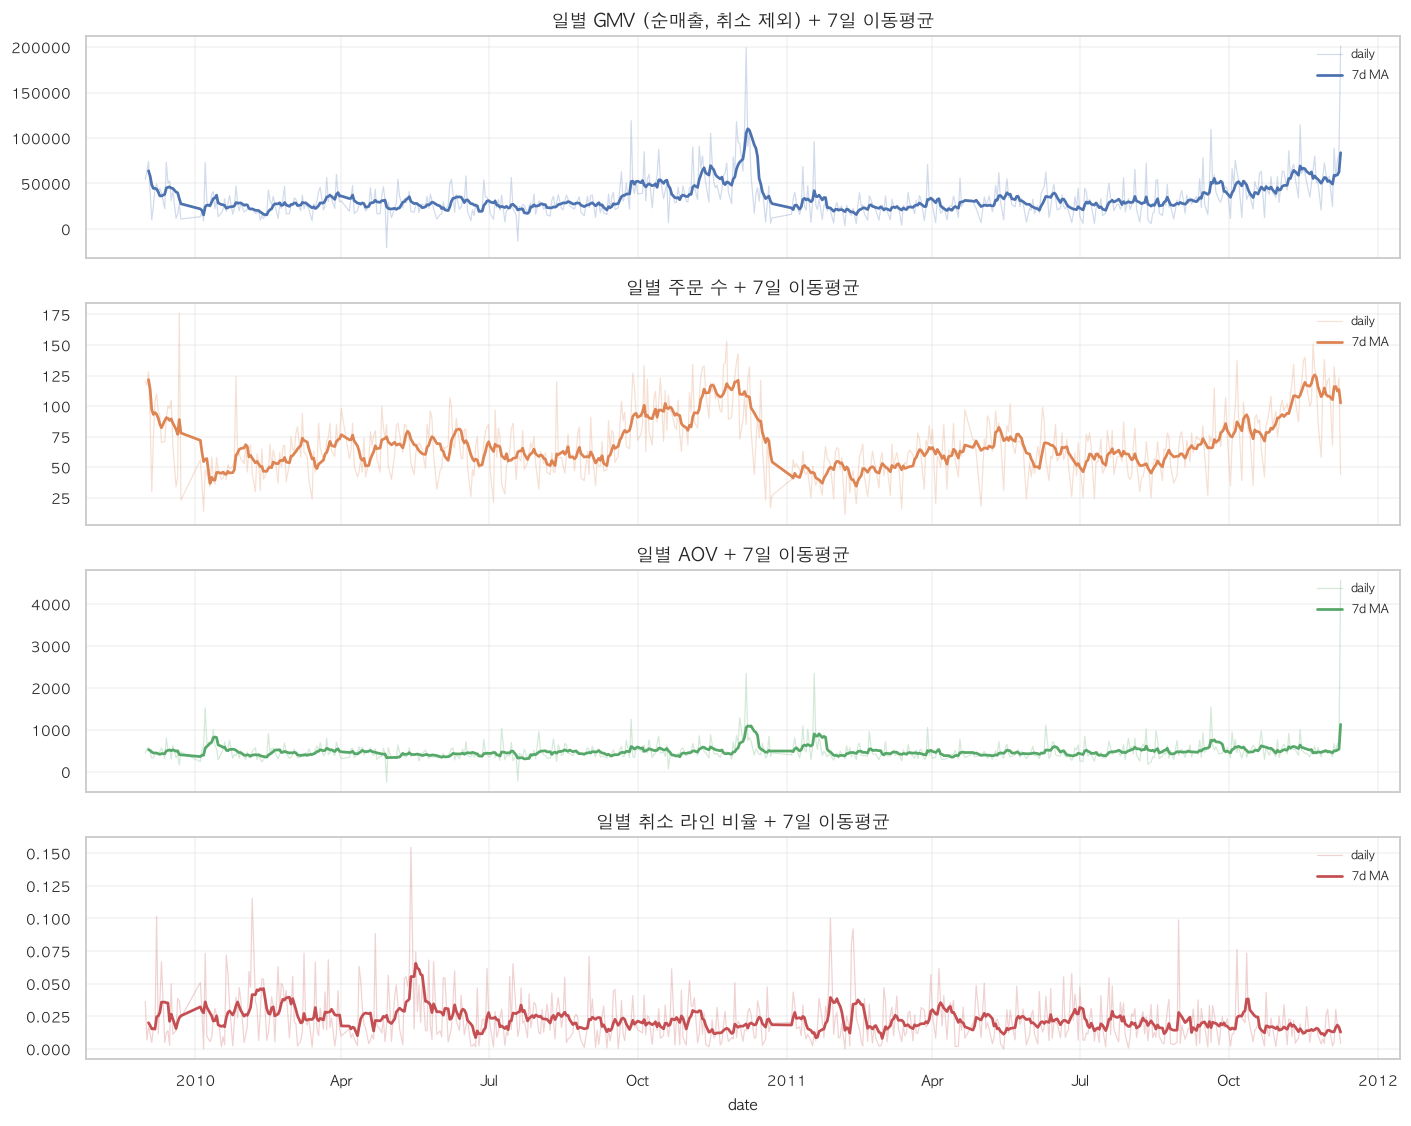

In [6]:
plot_metric_stack(
    {
        "gmv": daily["gmv"],
        "orders": daily["orders"],
        "aov": daily["aov"],
        "cancel_rate": daily["cancel_rate"],
    },
    title_map={
        "gmv": "일별 GMV (순매출, 취소 제외) + 7일 이동평균",
        "orders": "일별 주문 수 + 7일 이동평균",
        "aov": "일별 AOV + 7일 이동평균",
        "cancel_rate": "일별 취소 라인 비율 + 7일 이동평균",
    },
    colors={"gmv": "C0", "orders": "C1", "aov": "C2", "cancel_rate": "C3"},
    rolling=7,
)

**STL 분해 — 해석 방법**
- **Trend:** 천천히 바뀌는 수준(성장/쇠퇴). 하루 스파이크는 여기 안 들어간다.
- **Weekly seasonal:** 요일 패턴(예: 목·금 ↑ / 주말 ↓). `period=7` 기준.
- **Residual:** 추세·요일을 뺀 나머지(프로모·이상·미설명 변동).
- 계절/추세 강도가 크면, 전후 평균만으로 드리프트를 판정하면 캘린더를 오탐하기 쉽다.


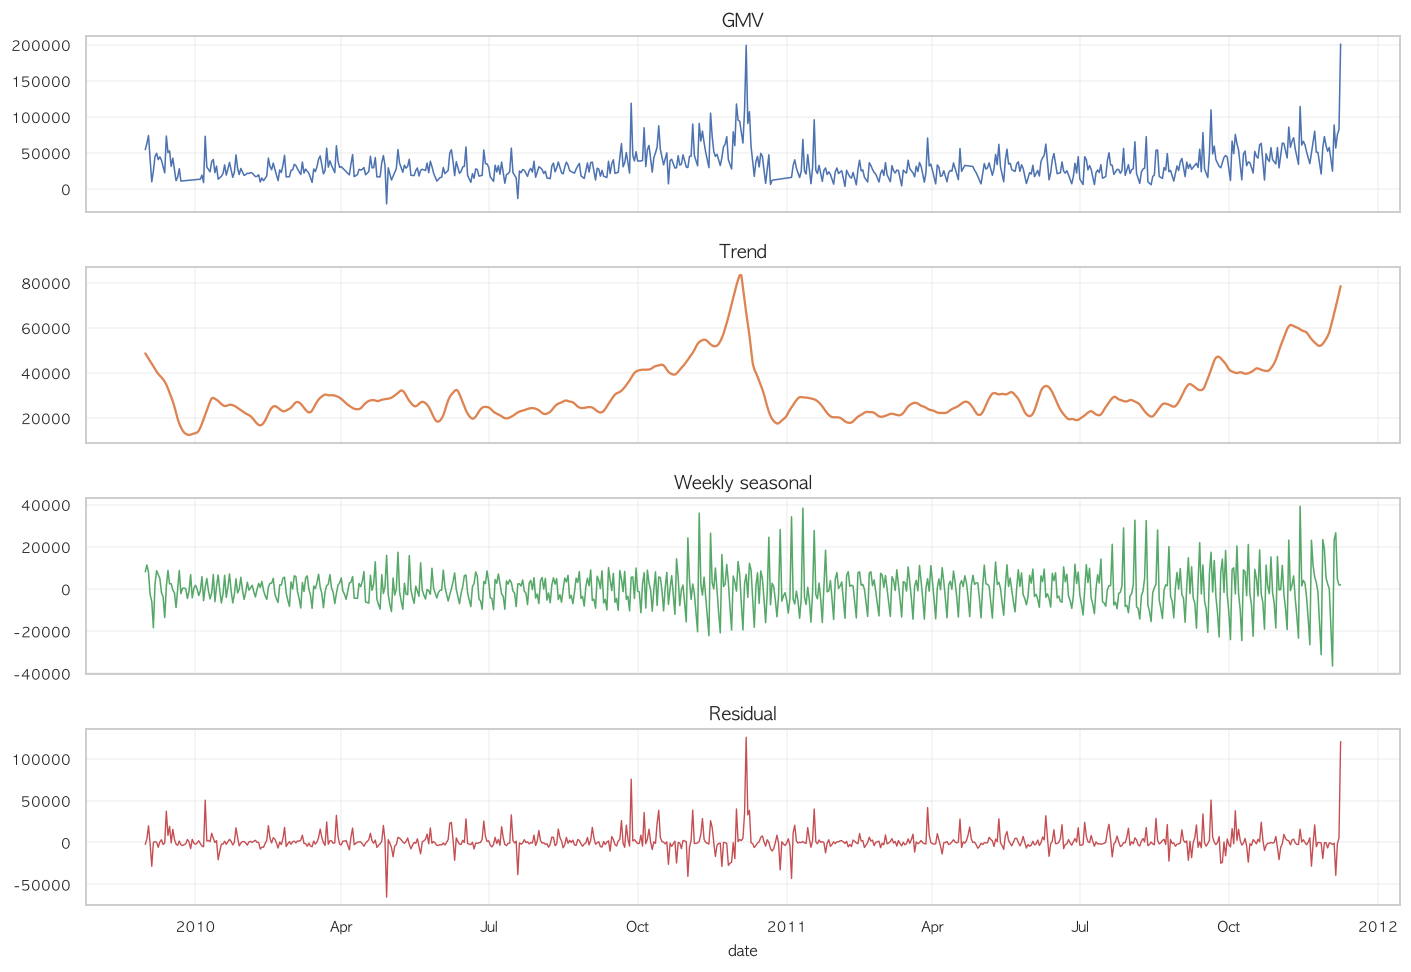

계절 강도(주): 0.349
추세 강도: 0.37


In [7]:
gmv = daily["gmv"].interpolate(limit_direction="both")
stl = STL(gmv, period=7, robust=True).fit()
fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
axes[0].plot(gmv.index, gmv.values, lw=1.0)
axes[0].set_title("GMV")
axes[1].plot(stl.trend.index, stl.trend.values, color="C1", lw=1.5)
axes[1].set_title("Trend")
axes[2].plot(stl.seasonal.index, stl.seasonal.values, color="C2", lw=1.0)
axes[2].set_title("Weekly seasonal")
axes[3].plot(stl.resid.index, stl.resid.values, color="C3", lw=0.9)
axes[3].set_title("Residual")
finish_figure(fig, axes, date_axis=True)
print("계절 강도(주):", round(np.var(stl.seasonal) / (np.var(stl.seasonal + stl.resid) + 1e-9), 3))
print("추세 강도:", round(np.var(stl.trend.dropna()) / (np.var(gmv) + 1e-9), 3))

### 3.2 요일 × 월 히트맵 — 캘린더 효과

**해석 방법**
- 셀 값 = 해당 **요일 × 월**에 속한 날들의 **일별 GMV 평균**(합계 아님).
- 색이 진할수록 그날·그달의 하루 평균 거래액이 크다.
- 예: `Monday × 11`이 진하면 → **“11월 월요일에 평균적으로 하루 GMV가 높다”**.
- STL이 잡는 주간 계절에 **월(시즌)** 축을 겹쳐, 연말·특정 요일 효과를 눈으로 확인한다.


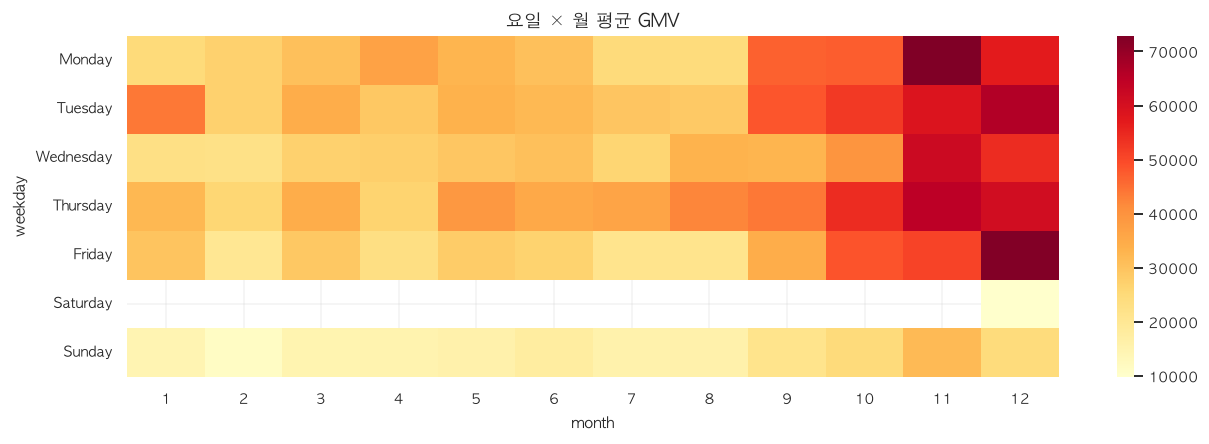

In [8]:
cal = daily["gmv"].to_frame()
cal["weekday"] = cal.index.day_name()
cal["month"] = cal.index.month
heat = cal.pivot_table(index="weekday", columns="month", values="gmv", aggfunc="mean")
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heat = heat.reindex(order)
fig, ax = plt.subplots(figsize=(12, 4.2))
sns.heatmap(heat, cmap="YlOrRd", ax=ax, annot=False)
ax.set_title("요일 × 월 평균 GMV")
ax.set_xlabel("month")
ax.set_ylabel("weekday")
fig.tight_layout()
plt.show()

### 3.3 국가 믹스 — 총량이 아니라 구성

**해석 방법**
- 세로축은 금액이 아니라 **매출 점유율(0~1)**. 밴드 두께 = 그 국가의 비중.
- 총 GMV가 비슷해도 밴드 구성이 바뀌면 **믹스 드리프트**.
- 특정 국가 밴드가 두꺼워지면 “그 시장 의존도가 커졌다”로 읽는다 (`Other`는 상위 제외 합).


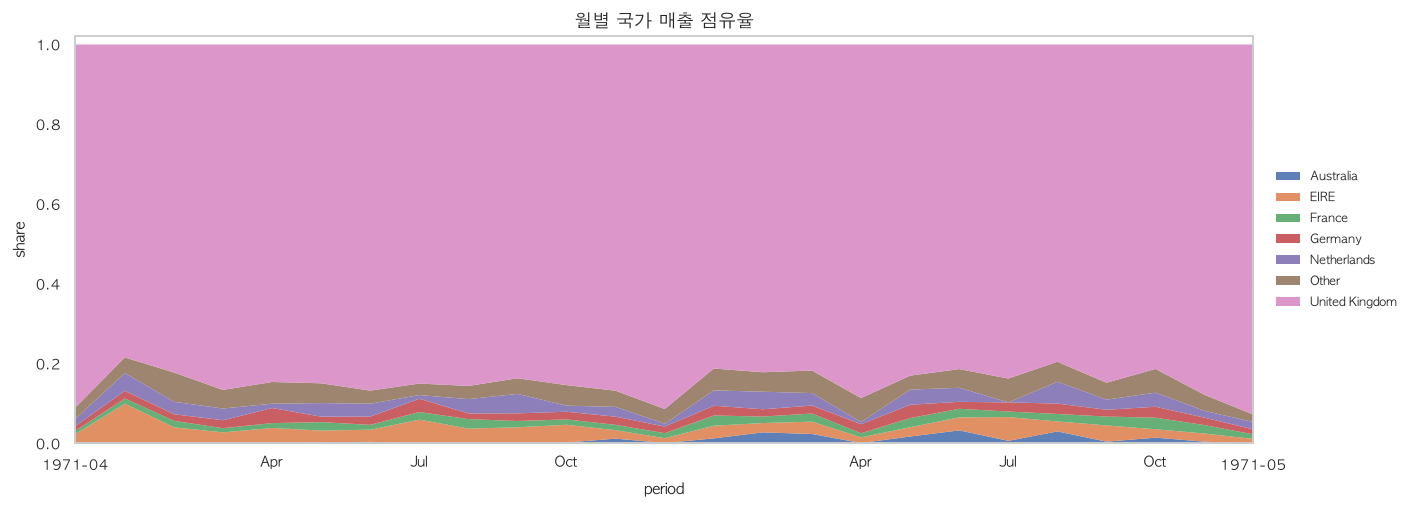

Country,Australia,EIRE,France,Germany,Netherlands,Other,United Kingdom
period,,,,,,,
2009-12-01,0.000,0.024,0.008,0.012,0.018,0.028,0.909
2010-12-01,0.001,0.012,0.013,0.017,0.007,0.037,0.913
2011-12-01,0.000,0.011,0.011,0.012,0.018,0.019,0.928


In [9]:
country_share = mix_shares(sold, "Date", "Country", "Revenue", freq="M", top_n=6)
fig, ax = plt.subplots(figsize=(13, 4.8))
country_share.plot.area(ax=ax, stacked=True, alpha=0.9, linewidth=0)
style_area(ax, "월별 국가 매출 점유율")
format_date_axis(ax, locator="month")
fig.tight_layout()
plt.show()
display(country_share.iloc[[0, len(country_share)//2, -1]].round(3))

### 3.4 SKU 파레토 — 카탈로그 집중도

**해석 방법**
- x = SKU를 매출 순으로 쌓은 **누적 비율**, y = 그 SKU들이 차지하는 **매출 누적 비율**.
- 곡선이 왼쪽 위로 급하면 **소수 SKU에 매출이 집중**(헤드 의존).
- 점선(0.8)에 빨리 닿을수록 파레토가 강하다. 집중도가 바뀌면 이후 SKU churn·믹스 해석에 영향.


SKU 수: 4985
상위 1% SKU 매출 비중: 0.218
상위 20% SKU 매출 비중: 0.804


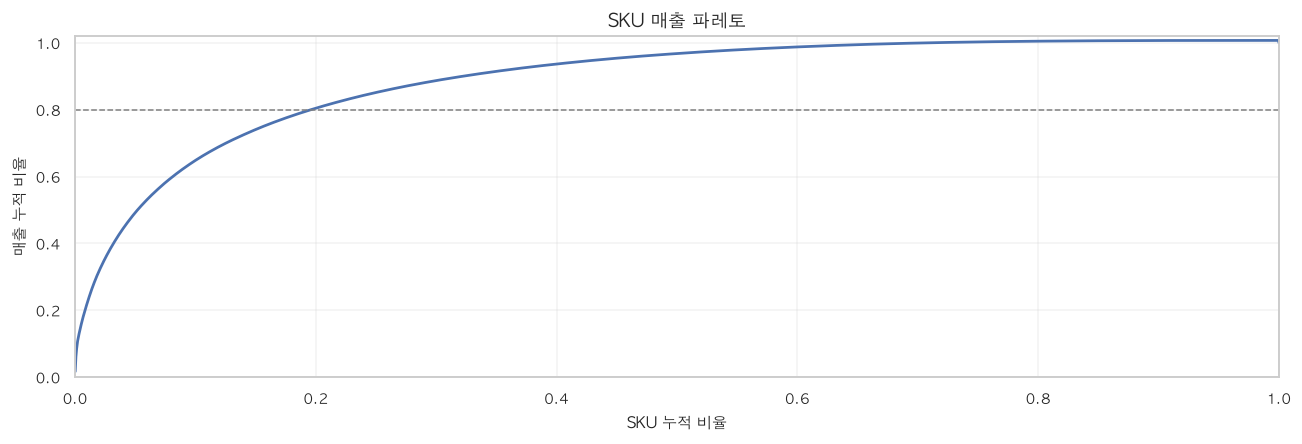

In [10]:
sku_gmv = sold.groupby("StockCode")["Revenue"].sum().sort_values(ascending=False)
pareto = sku_gmv.cumsum() / sku_gmv.sum()
print("SKU 수:", len(sku_gmv))
print("상위 1% SKU 매출 비중:", round(pareto.iloc[max(int(len(pareto)*0.01)-1, 0)], 3))
print("상위 20% SKU 매출 비중:", round(pareto.iloc[max(int(len(pareto)*0.20)-1, 0)], 3))
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(np.linspace(0, 1, len(pareto)), pareto.values, lw=1.8)
ax.axhline(0.8, color="gray", ls="--", lw=1)
ax.set_title("SKU 매출 파레토")
ax.set_xlabel("SKU 누적 비율")
ax.set_ylabel("매출 누적 비율")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
fig.tight_layout()
plt.show()

## 4. 드리프트 재현 — Online Retail II

비교 윈도우를 **2010년** vs **2011년**(데이터가 있는 구간)으로 둔다.
같은 시즌(연말)이 양쪽에 들어가므로 순수 계절만의 차이는 줄어든다.

측정 층:

1. **공변량/KPI 분포:** PSI, KS, Wasserstein (일별 GMV, AOV)
2. **구성:** 국가 매출 점유율 Total Variation / JS
3. **엔티티:** SKU Jaccard, new/dropped ratio
4. **기여 분해:** volume / mix / price
5. **롤링 점수:** 첫 30일을 베이스라인으로 둔 이동 창

**표(숫자) 해석**
- **PSI / KS:** 두 기간 일별 지표 분포가 얼마나 다른지. 클수록 분포 이동.
- **mix TV / JS:** 국가 점유율 벡터 거리. 총량과 별개로 “구성” 변화.
- **SKU churn:** 한쪽에만 있는 SKU 비율·Jaccard. 카탈로그 교체 강도.


In [11]:
base_mask = (sold["InvoiceDate"] >= "2010-01-01") & (sold["InvoiceDate"] < "2011-01-01")
cur_mask = (sold["InvoiceDate"] >= "2011-01-01") & (sold["InvoiceDate"] < "2012-01-01")
print("baseline lines", int(base_mask.sum()), "current lines", int(cur_mask.sum()))

gmv_cmp = compare_windows(
    daily["gmv"].dropna(),
    ("2010-01-01", "2010-12-31"),
    ("2011-01-01", "2011-12-09"),
    mix_base=sold.loc[base_mask].groupby("Country")["Revenue"].sum(),
    mix_cur=sold.loc[cur_mask].groupby("Country")["Revenue"].sum(),
)
aov_cmp = compare_windows(
    daily["aov"].dropna(),
    ("2010-01-01", "2010-12-31"),
    ("2011-01-01", "2011-12-09"),
)
churn = entity_churn(sold, "Date", "StockCode", base_mask, cur_mask)
decomp = revenue_decomposition(sold, "Country", "Quantity", "Revenue", base_mask, cur_mask)

summary = pd.DataFrame(
    {
        "gmv": gmv_cmp,
        "aov": aov_cmp,
    }
).T
display(summary.round(4))
print("SKU churn")
display(pd.Series(churn).to_frame("value").round(4))
display(decomp.round(2))

baseline lines 510694 current lines 489603


,baseline_mean,current_mean,mean_rel_change,psi,dist_ks_stat,dist_ks_pvalue,dist_wasserstein,mix_tv,mix_js
gmv,34118.7932,34459.0606,0.0100,0.0858,0.0633,0.5724,2327.3363,0.0339,0.0049
aov,477.4716,510.5258,0.0692,0.1205,0.0951,0.1315,35.0657,NaN,NaN


SKU churn


,value
baseline_entities,4135.0000
current_entities,3835.0000
retained,3171.0000
new,664.0000
dropped,964.0000
new_ratio,0.1731
dropped_ratio,0.2331
jaccard,0.6608


,component,value
0,volume,-1079465.66
1,mix,347565.38
2,price,385332.18
3,actual_delta,-346568.10
4,explained,-346568.10


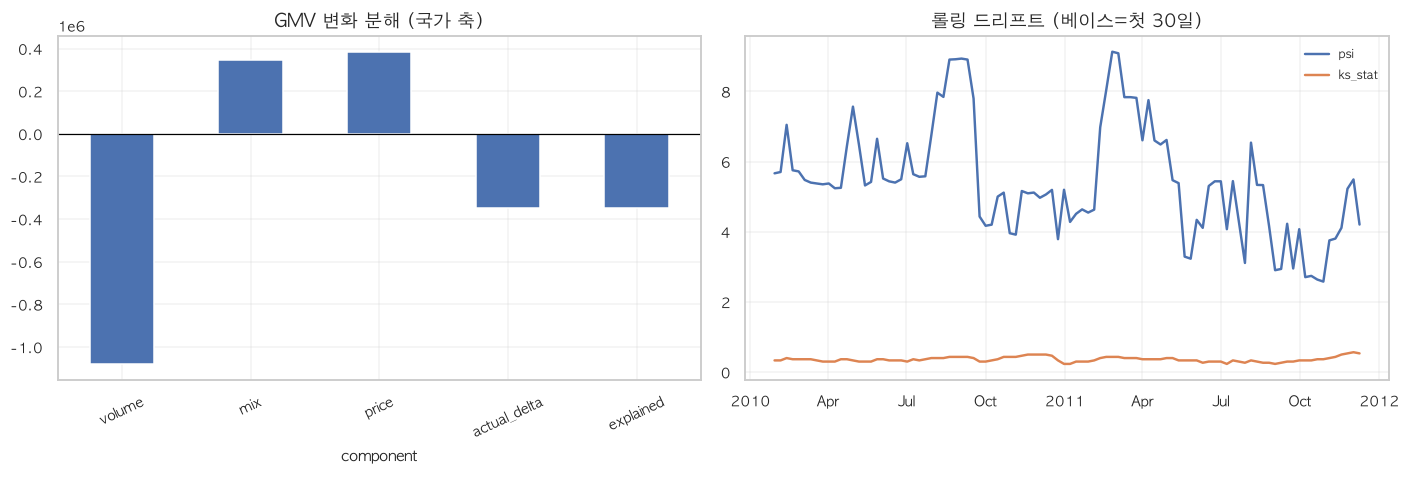

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
decomp.set_index("component")["value"].plot.bar(ax=axes[0], color="C0")
axes[0].set_title("GMV 변화 분해 (국가 축)")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].tick_params(axis="x", rotation=25)

roll = rolling_drift(daily["gmv"].interpolate(limit_direction="both"), window=30, step=7)
axes[1].plot(roll.index, roll["psi"], label="psi", lw=1.6)
axes[1].plot(roll.index, roll["ks_stat"], label="ks_stat", lw=1.6)
axes[1].set_title("롤링 드리프트 (베이스=첫 30일)")
axes[1].legend(frameon=False)
format_date_axis(axes[1])
fig.tight_layout()
plt.show()

**막대·롤링 차트 해석**
- **GMV 변화 분해:** ΔGMV를 volume / mix / price 등으로 나눈 기여. 막대가 +면 그 요인이 매출을 올렸고, −면 깎았다.
- **롤링 PSI·KS:** 첫 30일을 베이스로, 이후 30일 창이 베이스와 얼마나 다른지. 선이 올라가는 시점 ≈ “언제 깨지기 시작했는지”.
- PSI 휴리스틱(관례): **0.1 미만 안정**, **0.1–0.25 주의**, **0.25 이상 유의**.
- 커머스는 계절·프로모가 크므로 **원 시계열 PSI**와 **STL 잔차 PSI**를 같이 보는 편이 안전하다.


In [13]:
resid = stl.resid.dropna()
resid_cmp = compare_windows(resid, ("2010-01-01", "2010-12-31"), ("2011-01-01", "2011-12-09"))
print("GMV 원시계열 PSI", round(gmv_cmp["psi"], 4), "KS", round(gmv_cmp["dist_ks_stat"], 4))
print("GMV 잔차 PSI   ", round(resid_cmp["psi"], 4), "KS", round(resid_cmp["dist_ks_stat"], 4))

GMV 원시계열 PSI 0.0858 KS 0.0633
GMV 잔차 PSI    0.0329 KS 0.0491


## 5. Olist — 관계형 커머스 (주문 수명주기)

Olist는 라인이 아니라 **주문 팩트 + 차원** 이다. 시계열 슬롯이 매출만이 아니다.

- `order_purchase_timestamp` → 수요
- `order_approved_at` / carrier / customer delivered → 운영 리드타임
- `product_category` → 믹스
- `payment_type` → 결제 구성
- `review_score` → 품질 결과

**KPI 스택 해석**
- **GMV·주문:** 수요/규모. 초반·끝은 관측이 희소해 안정 구간(2017–2018-08)만 본다.
- **delivery_days:** 길어지면 운영 악화 신호(매출과 축이 다름).
- **review_score:** 품질 결과. 배송 지연과 같이 보면 원인 후보를 좁힐 수 있다.


In [14]:
olist = load_olist()
for name, df in olist.items():
    print(f"{name:12s} {df.shape}  {list(df.columns)[:8]}")

orders       (99441, 8)  ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
items        (112650, 7)  ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
payments     (103886, 5)  ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
reviews      (99224, 7)  ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
products     (32951, 9)  ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm']
customers    (99441, 5)  ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
sellers      (3095, 4)  ['seller_id', 

In [15]:
orders = olist["orders"].copy()
items = olist["items"].merge(
    olist["products"][["product_id", "product_category_name"]],
    on="product_id",
    how="left",
).merge(olist["categories"], on="product_category_name", how="left")
items["category"] = items["product_category_name_english"].fillna("unknown")
line = items.merge(
    orders[
        [
            "order_id",
            "customer_id",
            "order_status",
            "order_purchase_timestamp",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
        ]
    ],
    on="order_id",
    how="left",
)
line["Date"] = line["order_purchase_timestamp"].dt.normalize()
line["Revenue"] = line["price"]
line["Qty"] = 1

orders["Date"] = orders["order_purchase_timestamp"].dt.normalize()
orders["delivery_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400
orders["delay_days"] = (
    orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

print("주문 기간:", orders["order_purchase_timestamp"].min(), "~", orders["order_purchase_timestamp"].max())
print("상태 분포")
display(orders["order_status"].value_counts(normalize=True).round(3).to_frame("share"))
display(line.head(3))

주문 기간: 2016-09-04 21:15:19 ~ 2018-10-17 17:30:18
상태 분포


,share
order_status,
delivered,0.970
shipped,0.011
canceled,0.006
unavailable,0.006
invoiced,0.003
processing,0.003
created,0.000
approved,0.000


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,category,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,Date,Revenue,Qty
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,cool_stuff,cool_stuff,cool_stuff,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,2017-09-13,58.9,1
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,pet_shop,pet_shop,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,2017-04-26,239.9,1
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,moveis_decoracao,furniture_decor,furniture_decor,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,2018-01-14,199.0,1


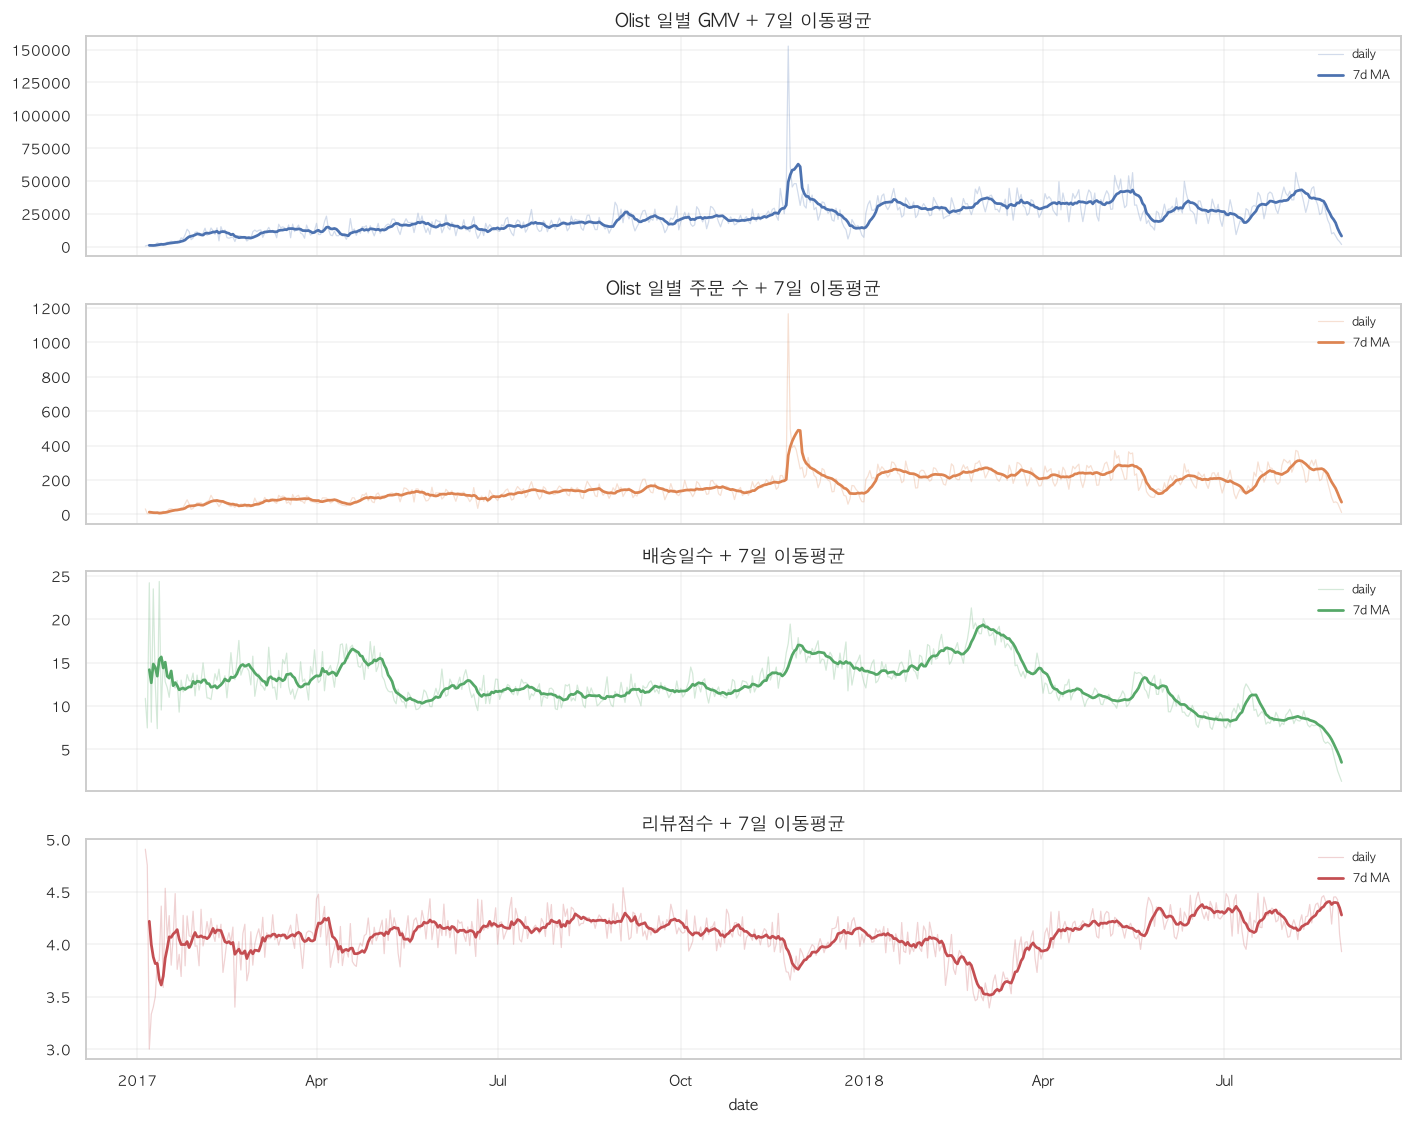

In [16]:
olist_daily = commerce_daily_metrics(
    line.dropna(subset=["Date"]),
    date_col="Date",
    revenue_col="Revenue",
    order_col="order_id",
    qty_col="Qty",
    customer_col="customer_id",
)
sla = (
    orders.dropna(subset=["Date", "delivery_days"])
    .groupby("Date")
    .agg(delivery_days=("delivery_days", "mean"), delay_days=("delay_days", "mean"), n=("order_id", "size"))
)
review_daily = (
    olist["reviews"]
    .merge(orders[["order_id", "Date"]], on="order_id", how="left")
    .dropna(subset=["Date"])
    .groupby("Date")["review_score"]
    .mean()
)
olist_daily = olist_daily.join(sla[["delivery_days", "delay_days"]], how="left")
olist_daily = olist_daily.join(review_daily.rename("review_score"), how="left")

# 초반/끝은 관측이 희소하므로 안정 구간만
stable = olist_daily.loc["2017-01-01":"2018-08-31"]

plot_metric_stack(
    {
        "gmv": stable["gmv"],
        "orders": stable["orders"],
        "delivery_days": stable["delivery_days"],
        "review_score": stable["review_score"],
    },
    title_map={
        "gmv": "Olist 일별 GMV + 7일 이동평균",
        "orders": "Olist 일별 주문 수 + 7일 이동평균",
        "delivery_days": "배송일수 + 7일 이동평균",
        "review_score": "리뷰점수 + 7일 이동평균",
    },
    colors={"gmv": "C0", "orders": "C1", "delivery_days": "C2", "review_score": "C3"},
)

### 5.1 카테고리·결제 믹스

**해석 방법**
- 둘 다 **점유율(0~1)** area. 왼쪽=상품 카테고리, 오른쪽=결제수단.
- 밴드가 시간에 따라 두꺼워/얇아지면 해당 축의 **구성 시프트**.
- 결제 믹스 변화는 상품 믹스와 무관한 **금융/채널 드리프트**일 수 있다.


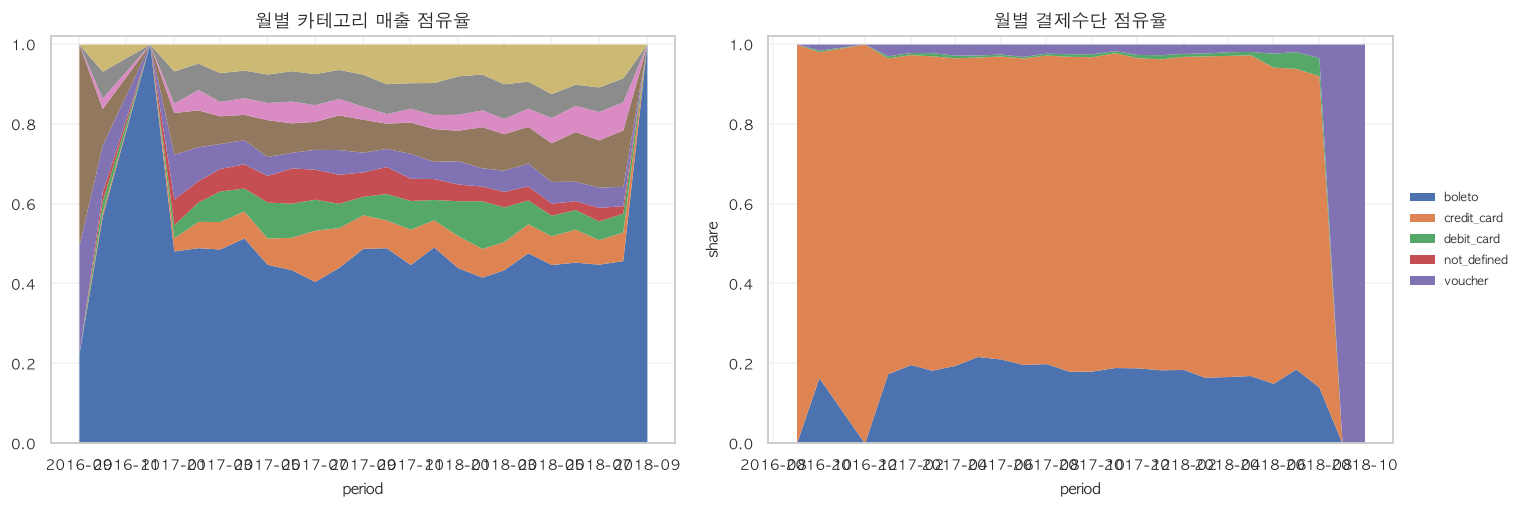

In [17]:
cat_share = mix_shares(line.dropna(subset=["Date"]), "Date", "category", "Revenue", freq="M", top_n=8)
pay = olist["payments"].merge(orders[["order_id", "Date"]], on="order_id", how="left")
pay_share = mix_shares(pay.dropna(subset=["Date"]), "Date", "payment_type", "payment_value", freq="M", top_n=5)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
cat_share.plot.area(ax=axes[0], stacked=True, linewidth=0, legend=False)
axes[0].set_title("월별 카테고리 매출 점유율")
axes[0].set_ylim(0, 1.02)
pay_share.plot.area(ax=axes[1], stacked=True, linewidth=0)
style_area(axes[1], "월별 결제수단 점유율")
for ax in axes:
    format_date_axis(ax, locator="month")
fig.tight_layout()
plt.show()

### 5.2 2017 vs 2018 드리프트

**해석 방법**
- 표: GMV·배송일 분포 비교(PSI/KS) + 카테고리 믹스 + product churn.
- **막대(기여 분해):** 2017→2018 GMV 변화를 카테고리 축의 volume/mix/price로 설명.
- “매출이 늘었는데 mix 기여가 −”이면, 성장은 볼륨인데 구성은 불리하게 바뀐 식으로 읽는다.


,baseline_mean,current_mean,mean_rel_change,psi,dist_ks_stat,dist_ks_pvalue,dist_wasserstein,mix_tv,mix_js
gmv,17052.0969,30646.9120,0.7973,2.4090,0.6803,0.0,14153.2338,0.1528,0.0238
delivery_days,12.8072,11.9762,-0.0649,0.5874,0.2918,0.0,1.4703,NaN,NaN


product_id churn


,value
baseline_entities,17273.0000
current_entities,20495.0000
retained,4981.0000
new,15514.0000
dropped,12292.0000
new_ratio,0.7570
dropped_ratio,0.7116
jaccard,0.1519


,component,value
0,volume,1276932.99
1,mix,130166.90
2,price,-177001.07
3,actual_delta,1230098.82
4,explained,1230098.82


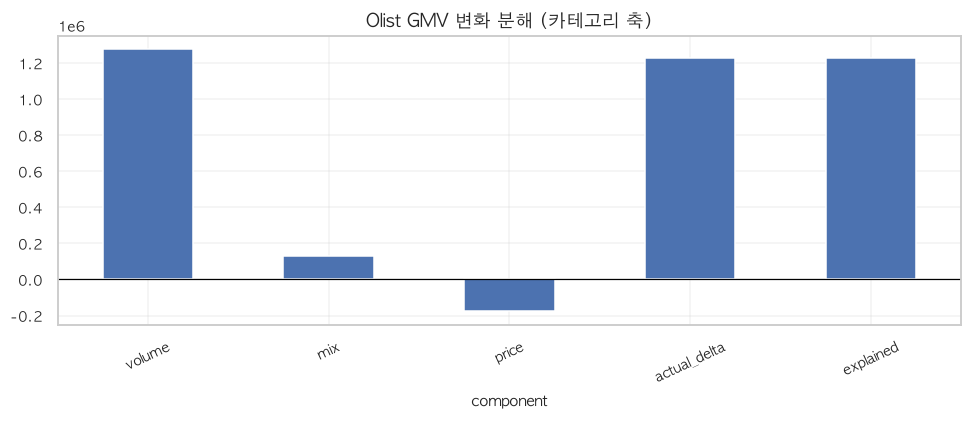

In [18]:
o_base = (line["Date"] >= "2017-01-01") & (line["Date"] < "2018-01-01")
o_cur = (line["Date"] >= "2018-01-01") & (line["Date"] < "2018-09-01")

olist_gmv_cmp = compare_windows(
    stable["gmv"].dropna(),
    ("2017-01-01", "2017-12-31"),
    ("2018-01-01", "2018-08-31"),
    mix_base=line.loc[o_base].groupby("category")["Revenue"].sum(),
    mix_cur=line.loc[o_cur].groupby("category")["Revenue"].sum(),
)
olist_sla_cmp = compare_windows(
    stable["delivery_days"].dropna(),
    ("2017-01-01", "2017-12-31"),
    ("2018-01-01", "2018-08-31"),
)
olist_churn = entity_churn(line, "Date", "product_id", o_base, o_cur)
olist_decomp = revenue_decomposition(line, "category", "Qty", "Revenue", o_base, o_cur)

display(pd.DataFrame({"gmv": olist_gmv_cmp, "delivery_days": olist_sla_cmp}).T.round(4))
print("product_id churn")
display(pd.Series(olist_churn).to_frame("value").round(4))
display(olist_decomp.round(2))

fig, ax = plt.subplots(figsize=(9, 4))
olist_decomp.set_index("component")["value"].plot.bar(ax=ax, color="C0")
ax.set_title("Olist GMV 변화 분해 (카테고리 축)")
ax.axhline(0, color="black", lw=0.8)
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.show()

## 6. Superstore — 믹스 시프트가 잘 보이는 샘플

실제 거래 원장은 아니지만 Category / Segment / Region 축이 깨끗해서
**구성 드리프트 시각화 패턴**을 확인하기 좋다.

**차트 해석**
- **월별 Sales / AOV:** 규모 vs 객단가. Sales↑·AOV↓면 저단가 주문 비중 증가 후보.
- **구성 area(카테고리·세그먼트·지역):** 밴드 두께=매출 점유율. 축마다 시프트가 다르면 “어느 차원이 깨졌는지”를 분리한다.
- 아래 TV 숫자는 두 해 점유율 벡터 거리(클수록 믹스 변화 큼).


(9994, 23) 2015-01-03 00:00:00 ~ 2018-12-30 00:00:00


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Date,YearMonth
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136,2017-11-08,2017-11
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820,2017-11-08,2017-11
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714,2017-06-12,2017-06


{'Category': 3, 'Segment': 3, 'Region': 4}


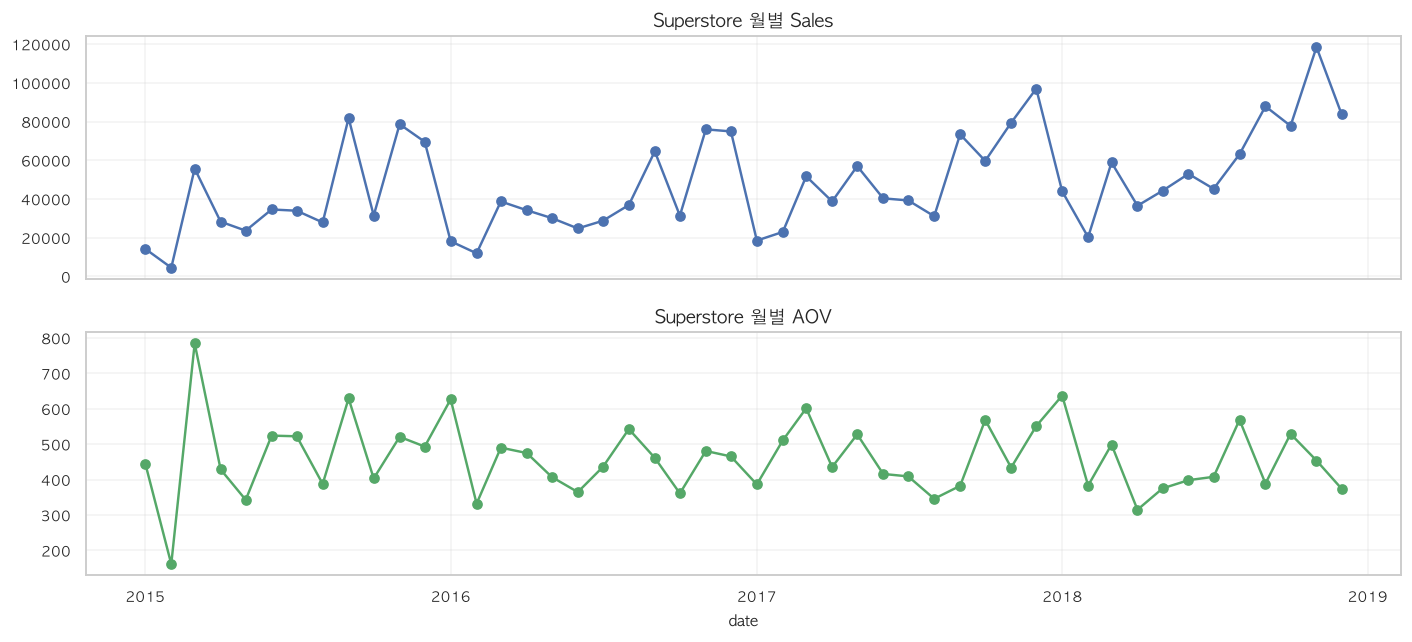

In [19]:
store = load_superstore()
print(store.shape, store["Order Date"].min(), "~", store["Order Date"].max())
display(store.head(3))
print(store[["Category", "Segment", "Region"]].nunique().to_dict())

store_daily = commerce_daily_metrics(
    store,
    date_col="Date",
    revenue_col="Sales",
    order_col="Order ID",
    qty_col="Quantity",
)
store_m = store_daily.resample("MS").sum(numeric_only=True)
store_m["aov"] = store_m["gmv"] / store_m["orders"].replace(0, np.nan)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(store_m.index, store_m["gmv"], marker="o", lw=1.6)
axes[0].set_title("Superstore 월별 Sales")
axes[1].plot(store_m.index, store_m["aov"], marker="o", color="C2", lw=1.6)
axes[1].set_title("Superstore 월별 AOV")
finish_figure(fig, axes, date_axis=True, locator="year")

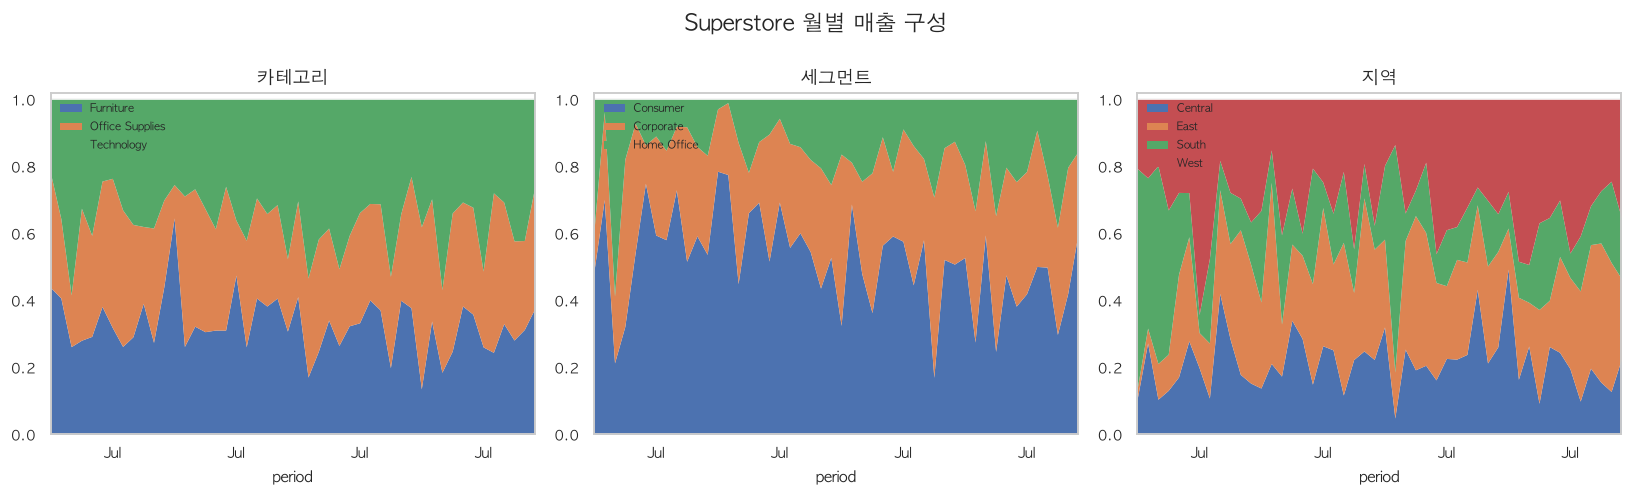

Category TV 2015 vs 2016: 0.0378
Region TV 2015 vs 2016: 0.0707


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True)
for ax, col, title in [
    (axes[0], "Category", "카테고리"),
    (axes[1], "Segment", "세그먼트"),
    (axes[2], "Region", "지역"),
]:
    mix_shares(store, "Date", col, "Sales", freq="M", top_n=6).plot.area(ax=ax, stacked=True, linewidth=0, legend=True)
    ax.set_title(title)
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=7, loc="upper left", frameon=False)
    format_date_axis(ax, locator="year")
fig.suptitle("Superstore 월별 매출 구성")
fig.tight_layout()
plt.show()

s_base = (store["Order Date"] >= "2015-01-01") & (store["Order Date"] < "2016-01-01")
s_cur = (store["Order Date"] >= "2016-01-01") & (store["Order Date"] < "2017-01-01")
print("Category TV 2015 vs 2016:", round(total_variation(
    store.loc[s_base].groupby("Category")["Sales"].sum(),
    store.loc[s_cur].groupby("Category")["Sales"].sum(),
), 4))
print("Region TV 2015 vs 2016:", round(total_variation(
    store.loc[s_base].groupby("Region")["Sales"].sum(),
    store.loc[s_cur].groupby("Region")["Sales"].sum(),
), 4))

## 7. 인사이트 — 커머스 드리프트를 어떻게 분석할 것인가

세 데이터셋을 펼쳐 보면, 커머스 드리프트는 단일 KS 검정으로 끝나지 않는다.

### 반드시 분리할 층

1. **볼륨 드리프트:** 주문수·수량·GMV 수준
2. **가격/단가 드리프트:** AOV, ASP, 할인
3. **믹스 드리프트:** 카테고리·국가·채널·결제수단 점유율 (TV, JS)
4. **엔티티 드리프트:** SKU/셀러/고객 집합의 생성·소멸 (Jaccard, new ratio)
5. **운영 드리프트:** 취소비, 배송일수, 리뷰점수 — 매출과 다른 시계열
6. **계절 vs 구조:** STL/요일-월 히트맵으로 캘린더를 먼저 제거

기존 timeseries 플러그인은 컬럼 분포의 상대 차이 + 범주 TV를 본다.
커머스 도메인 킷이라면 그 위에 **KPI 슬롯(GMV/AOV/SLA)** 과 **믹스 슬롯**, **카탈로그 churn** 을
명시적으로 두는 편이 맞다.

### 비교 윈도우 설계

- 전후 90일 단순 비교는 연말/캠페인을 드리프트로 오탐한다.
- 전년 동기, 요일 정렬, 잔차 시계열이 기본이다.
- 롤링 점수는 "언제 깨졌는지"를 보여 주고, 분해는 "왜 매출이 바뀌었는지"를 보여 준다.

### 다음 실험 후보

- 카테고리별 계층 드리프트 (M5 스타일, Kaggle 셋)
- 프로모션 캘린더를 공변량으로 넣은 conditional drift
- 주문 퍼널(생성→승인→배송) 단계별 리드타임 드리프트

In [21]:
insight = pd.DataFrame(
    [
        ["UCI Retail II", "invoice line", "GMV/AOV/cancel, country mix, SKU churn", "연말 계절이 KPI PSI를 크게 만듦"],
        ["Olist", "order + item + dim", "GMV + delivery SLA + review + category/pay mix", "성장기라 volume 성분이 큼, 카탈로그 교체도 큼"],
        ["Superstore", "order line (샘플)", "Category/Segment/Region mix 시각화", "실제 원장은 아니지만 믹스 차트 패턴 확인용"],
    ],
    columns=["dataset", "grain", "drift_slots", "note"],
)
display(insight)

,dataset,grain,drift_slots,note
0,UCI Retail II,invoice line,"GMV/AOV/cancel, country mix, SKU churn",연말 계절이 KPI PSI를 크게 만듦
1,Olist,order + item + dim,GMV + delivery SLA + review + category/pay mix,"성장기라 volume 성분이 큼, 카탈로그 교체도 큼"
2,Superstore,order line (샘플),Category/Segment/Region mix 시각화,실제 원장은 아니지만 믹스 차트 패턴 확인용
